In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import requests
import time

from nhlpy import NHLClient

In [3]:
def get_target_players(season="20222023", target_count=40):
    """
    Dynamically generates a list of (Player_ID, Team_Abbr) tuples for the top
    point producers in a given season, filtering out traded players.
    """
    # Hit the official NHL Stats API for the season's point leaders
    # We pull the top 100 to ensure we have enough buffer after filtering out trades
    url = (
        "https://api.nhle.com/stats/rest/en/skater/summary"
        "?isAggregate=false&isGame=false"
        "&sort=%5B%7B%22property%22:%22points%22,%22direction%22:%22DESC%22%7D%5D"
        "&start=0&limit=100" 
        f"&cayenneExp=seasonId={season}%20and%20gameTypeId=2"
    )
    
    response = requests.get(url).json()
    target_players = []
    
    for player in response['data']:
        # FILTER: If the teamAbbrevs contains a comma (e.g., "PIT, CAR"), they were traded.
        # We skip them to protect the 82-game master timeline.
        if ',' in player['teamAbbrevs']:
            continue
            
        player_id = player['playerId']
        team_abbr = player['teamAbbrevs']
        
        target_players.append((player_id, team_abbr))
        
        # Stop once we hit exactly 40 players
        if len(target_players) == target_count:
            break
            
    return target_players

# Generate the list automatically
target_players = get_target_players()

print(f"Generated target list of {len(target_players)} top-tier starters.")
# Peek at the first few to verify (McDavid, MacKinnon, Kucherov, etc.)
print(target_players[:5])

Generated target list of 40 top-tier starters.
[(8478402, 'EDM'), (8477934, 'EDM'), (8476453, 'TBL'), (8477956, 'BOS'), (8477492, 'COL')]


In [4]:
client = NHLClient()

season_str = "20232024"
all_players_data = []

# We want to pull data from the 2023-2024 NHL season,
# First we will pull the Team schedule for each player's team,
# Then pull the player's game log for the same season,
# We will then compare the two, if a player has missed a game we will record that as an injury.

for player_id, team_abbr in target_players:
    try:
        # Fetch Team Schedule
        schedule_data = client.schedule.team_season_schedule(team_abbr=team_abbr, season=season_str)
        team_games = [g for g in schedule_data['games'] if g['gameType'] == 2] # regular season games
        df_team = pd.DataFrame(team_games)[['gameDate']].rename(columns={'gameDate': 'Date'})
        df_team['Date'] = pd.to_datetime(df_team['Date'])
        df_team = df_team.sort_values('Date').reset_index(drop=True)
        df_team['Game_Number'] = df_team.index + 1
        
        # Fetch Player Log
        log_data = client.stats.player_game_log(player_id=player_id, season_id=season_str, game_type=2) 
        df_player = pd.DataFrame(log_data)[['gameDate', 'toi']].rename(columns={'gameDate': 'Date', 'toi': 'TOI'})
        df_player['Date'] = pd.to_datetime(df_player['Date'])
        
        # Merge & Assign States
        df = pd.merge(df_team, df_player, on='Date', how='left')
        df['Is_Injured'] = df['TOI'].isna().astype(int) # if no time on ice, then they did not play 
        df['Recent_Injuries'] = df['Is_Injured'].shift(1).rolling(window=3, min_periods=1).sum().fillna(0) # count how many of the last 3 games were missed.
        
        def assign_state(row):
            if row['Is_Injured'] == 1: return 'I'
            elif row['Recent_Injuries'] > 0: return 'V'
            else: return 'H'
            
        df['State'] = df.apply(assign_state, axis=1)
        
        # Tag the data with the player's ID before appending
        df['Player_ID'] = player_id
        all_players_data.append(df[['Player_ID', 'Date', 'Game_Number', 'State']])
        
        # delay to avoid hammering the API
        time.sleep(1.5) 
        
    except Exception as e:
        print(f"Error processing player {player_id}: {e}")

# Concatenate into a single Panel DataFrame
df_market = pd.concat(all_players_data, ignore_index=True)

# Shift strictly WITHIN each player's group
df_market['Next_State'] = df_market.groupby('Player_ID')['State'].shift(-1)

# Calculate the Market 3x3 Matrix P
transition_counts = pd.crosstab(df_market['State'], df_market['Next_State']) # count transitions
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0) # normalize to get values between 0 and 1
state_order = ['H', 'V', 'I']
transition_matrix = transition_matrix.reindex(index=state_order, columns=state_order).fillna(0) 

print("Market 82-Game Transition Matrix P:")
print(transition_matrix)

Market 82-Game Transition Matrix P:
Next_State         H         V         I
State                                   
H           0.983539  0.000000  0.016461
V           0.258503  0.639456  0.102041
I           0.000000  0.305085  0.694915


In [5]:
# Stationary Distribution found by solving pi(P-I) = 0
P = transition_matrix.to_numpy()

# Set up the system of equations: (P^T - I) * pi^T = 0
A = P.T - np.eye(3)

# Replace the last row with ones to enforce the constraint that the probabilities sum to 1
A[-1] = np.ones(3)

# The right-hand side of the equations: [0, 0, 1]^T
b = np.array([0, 0, 1])

# Solve the linear system A * x = b
pi = np.linalg.solve(A, b)

# Create a clean pandas Series for readability
stationary_dist = pd.Series(pi, index=['H', 'V', 'I'])

print("\nLong-Term Stationary Distribution (\u03C0):")
print(stationary_dist.to_string(float_format=lambda x: f"{x:.4f}"))

# Calculate expected games per 82-game season in each state
expected_games = stationary_dist * 82
print("\nExpected Games per Season:")
print(expected_games.to_string(float_format=lambda x: f"{x:.2f}"))


Long-Term Stationary Distribution (π):
H   0.8780
V   0.0559
I   0.0661

Expected Games per Season:
H   72.00
V    4.58
I    5.42


In [6]:
# Monte Carlo Simulations With Simple Mimple Markov Model
N = 10000
n_games = 82

total_injured = np.zeros(N)
total_episodes = np.zeros(N)
recovery_times = []

for i in range(N):
    current = 0
    trajectory = [current]

    # simulate one season
    for game in range(n_games - 1):
        current = np.random.choice([0, 1, 2], p=P[current, :])
        trajectory.append(current)
        
    trajectory = np.array(trajectory)

    # count games spent injured
    total_injured[i] = np.sum(trajectory == 2)

    # count injury episodes (separate periods spent in I)
    episodes = 0
    for j in range(1, len(trajectory)):
        if trajectory[j] == 2 and trajectory[j-1] != 2:
            episodes += 1
    total_episodes[i] = episodes

    # track recovery times (how many games from entering I to reaching H)
    injured = False
    injury_start = 0
    for j in range(len(trajectory)):
        if trajectory[j] == 2 and not injured:
            injured = True
            injury_start = j
        elif trajectory[j] == 0 and injured:
            recovery_times.append(j - injury_start)
            injured = False


In [7]:
mu_I = np.mean(total_injured)
err_I = np.std(total_injured) / np.sqrt(N)

mu_ep = np.mean(total_episodes)
err_ep = np.std(total_episodes) / np.sqrt(N)

print(f"Average games injured per season: {mu_I:.3f} +/- {err_I:.3f}")
print(f"Average injury episodes per season: {mu_ep:.3f} +/- {err_ep:.3f}")

Average games injured per season: 5.006 +/- 0.056
Average injury episodes per season: 1.581 +/- 0.015


In [8]:
p_none = np.mean(total_episodes == 0)
p_any = np.mean(total_episodes >= 1)
p_two_plus = np.mean(total_episodes >= 2)

err_none = np.std(total_episodes == 0) / np.sqrt(N)
err_any = np.std(total_episodes >= 1) / np.sqrt(N)
err_two = np.std(total_episodes >= 2) / np.sqrt(N)

print(f"P(injury-free season) = {p_none:.3f} +/- {err_none:.3f}")
print(f"P(at least 1 injury episode) = {p_any:.3f} +/- {err_any:.3f}")
print(f"P(at least 2 injury episodes) = {p_two_plus:.3f} +/- {err_two:.3f}")

P(injury-free season) = 0.271 +/- 0.004
P(at least 1 injury episode) = 0.729 +/- 0.004
P(at least 2 injury episodes) = 0.447 +/- 0.005


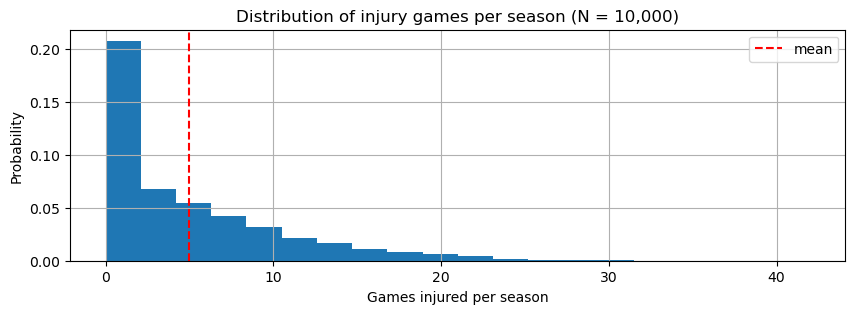

In [9]:
# Histogram of total injured games per season
plt.figure(figsize=(10,3))
plt.hist(total_injured, bins=20, density=True)
plt.grid(True)
plt.xlabel('Games injured per season')
plt.ylabel('Probability')
plt.axvline(np.mean(total_injured), color='red', linestyle='dashed', label='mean')
plt.legend()
plt.title('Distribution of injury games per season (N = 10,000)')
plt.savefig('distribution_injured_games.png')
plt.show()

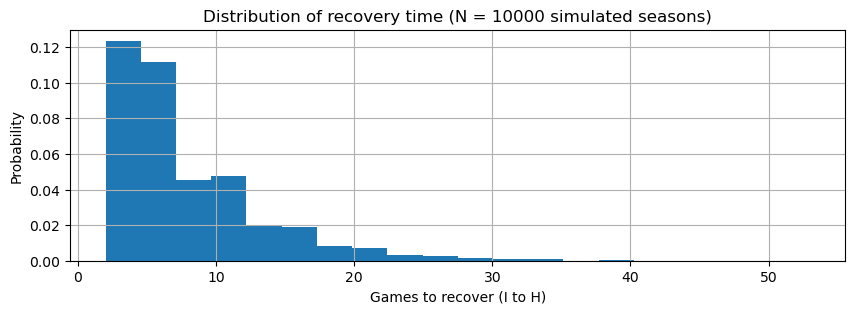

Recovery observations: 10507


In [10]:
# Histogram of recovery times (number of games in I before moving to H)
plt.figure(figsize=(10,3))
plt.hist(recovery_times, bins=20, density=True)
plt.grid(True)
plt.xlabel('Games to recover (I to H)')
plt.ylabel('Probability')
plt.title('Distribution of recovery time (N = 10000 simulated seasons)')
plt.savefig('distribution_recovery_time.png')
plt.show()

print(f"Recovery observations: {len(recovery_times)}")


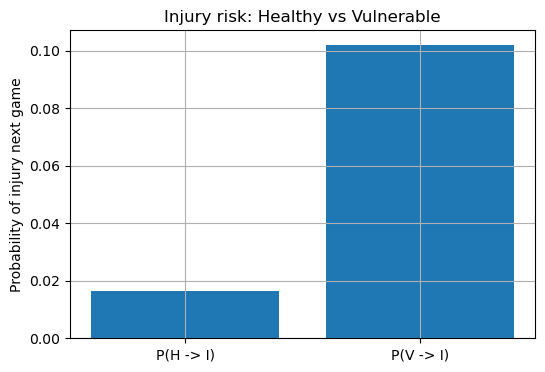

In [11]:
# Bar chart comparing injury rates starting from H vs V
plt.figure(figsize=(6,4))
labels = ['P(H -> I)', 'P(V -> I)']
values = [P[0, 2], P[1, 2]]
plt.bar(labels, values)
plt.grid(True)
plt.ylabel('Probability of injury next game')
plt.title('Injury risk: Healthy vs Vulnerable')
plt.savefig('injury_risk_comparison.png')
plt.show()


In [12]:
df = df_market.copy()
df['Prev_State'] = df.groupby('Player_ID')['State'].shift(1) # create a column that shows the previous state for each player
df['New_Injury_Flag'] = ((df['State'] == 'I') & (df['Prev_State'].isin(['H', 'V', np.nan]))).astype(int) # makes sure we are only counting a new injury once they have fully reutrned to H

# 2. Cumulative sum to calculate the player's current injury tier
df['Injury_Tier'] = df.groupby('Player_ID')['New_Injury_Flag'].cumsum() 

# 3. Cap the tier at n=3
df['Injury_Tier'] = df['Injury_Tier'].clip(upper=3)

def assign_tiered_state(row):
    base = row['State']
    tier = int(row['Injury_Tier'])
    
    if tier == 0:
        return 'H_0' 
    else:
        return f"{base}_{tier}"

df['Tiered_State'] = df.apply(assign_tiered_state, axis=1)

# Clean up temporary calculation columns
df = df.drop(columns=['Prev_State', 'New_Injury_Flag', 'Injury_Tier', 'State'])

df['Next_State'] = df.groupby('Player_ID')['Tiered_State'].shift(-1)

# Build the strict expected ordering for the matrix axes
state_order = ['H_0']
for i in range(1, 4):
    state_order.extend([f"I_{i}", f"V_{i}", f"H_{i}"])


transition_counts = pd.crosstab(df['Tiered_State'], df['Next_State']) # count the transitions 
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0) # normalize to get values between 0 and 1
transition_matrix = transition_matrix.reindex(index=state_order, columns=state_order).fillna(0) 

# check the row sum is one
for i in range(1, 4):
    row_sum = transition_matrix.loc[state_order[i-1], :].sum()
    assert np.isclose(row_sum, 1), f"Row {state_order[i-1]} sums to {row_sum}, not 1."

print(f"\n{len(state_order)}x{len(state_order)} Tiered Transition Matrix P:")
print(transition_matrix.head(10)) # Just printing the top corner for readability


10x10 Tiered Transition Matrix P:
Next_State         H_0       I_1       V_1       H_1       I_2       V_2  \
Tiered_State                                                               
H_0           0.986693  0.013307  0.000000  0.000000  0.000000  0.000000   
I_1           0.000000  0.714286  0.285714  0.000000  0.000000  0.000000   
V_1           0.000000  0.000000  0.656716  0.313433  0.029851  0.000000   
H_1           0.000000  0.000000  0.000000  0.976991  0.023009  0.000000   
I_2           0.000000  0.000000  0.000000  0.000000  0.744681  0.255319   
V_2           0.000000  0.000000  0.000000  0.000000  0.000000  0.657143   
H_2           0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
I_3           0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
V_3           0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
H_3           0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

Next_State         H_2       I_3       V_3       H_3

In [17]:
# Monte Carlo to find Stationary Distribution 
P = transition_matrix.to_numpy()
states = ['H_0', 'I_1', 'V_1', 'H_1', 'I_2', 'V_2', 'H_2', 'I_3', 'V_3', 'H_3']
n_simulations = 10000
n_steps = 1000  # Pushed to 1000 to find the stationary limit

# Initialize all 10,000 players in state 0 (H_0)
current_states = np.zeros(n_simulations, dtype=int)
distribution_history = []

# Run the vectorized simulation
for step in range(1, n_steps + 1):
    # Get the transition probabilities for each player's current state
    probs = P[current_states]
    cumulative_probs = np.cumsum(probs, axis=1)
    random_draws = np.random.rand(n_simulations)
    
    # Determine the next state
    current_states = (random_draws[:, None] < cumulative_probs).argmax(axis=1)
    
    # Record the distribution at key milestones (Game 82 and Game 1000)
    if step == 82 or step == 1000:
        counts = np.bincount(current_states, minlength=10)
        distribution = counts / n_simulations
        distribution_history.append((step, distribution))

# Format and print the results
df_results = pd.DataFrame(
    [dist for step, dist in distribution_history],
    columns=states,
    index=['Game 82 (Season End)', 'Game 1000 (Stationary Limit)']
)
stationary_dist = df_results.drop(index='Game 82 (Season End)')

print("\nSimulated State Distributions:")
print(stationary_dist.to_string(float_format=lambda x: f"{x:.4f}"))


Simulated State Distributions:
                                H_0    I_1    V_1    H_1    I_2    V_2    H_2    I_3    V_3    H_3
Game 1000 (Stationary Limit) 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.2349 0.2303 0.5348


In [19]:
# Starting in an injured state, how long does it take for a player to be fully healthy.
n_sims = 10000

# We want to measure the journey from Injury (I) to stabilized Health (H) 
tiers = [
    (1, 'I_1', 'H_1'),
    (2, 'I_2', 'H_2'),
    (3, 'I_3', 'H_3')
]

print("--- Expected Recovery Times (First Passage to H_k) ---\n")

for tier, start_state, end_state in tiers:
    start_idx = states.index(start_state)
    end_idx = states.index(end_state)
    
    # Drop 10,000 players into the starting Injury state
    current_states = np.full(n_sims, start_idx)
    steps_taken = np.zeros(n_sims)
    reached_target = np.zeros(n_sims, dtype=bool)
    
    step = 0
    # Run the simulation forward
    while not np.all(reached_target) and step < 1000:
        step += 1
        probs = P[current_states]
        cum_probs = np.cumsum(probs, axis=1)
        rands = np.random.rand(n_sims)
        current_states = (rands[:, None] < cum_probs).argmax(axis=1)
        
        # Identify who just reached the target state (H_k) for the VERY FIRST time
        just_reached = (current_states == end_idx) & (~reached_target)
        steps_taken[just_reached] = step
        reached_target[just_reached] = True
        
    avg_steps = np.mean(steps_taken[reached_target])
    success_rate = np.mean(reached_target) * 100
    
    print(f"Injury # {tier} ({start_state} -> {end_state}):")
    print(f"  -> Avg Games to Stabilize:  {avg_steps:.2f} games")
    print(f"  -> Successful Rehab Rate:   {success_rate:.1f}%\n")

--- Expected Recovery Times (First Passage to H_k) ---

Injury # 1 (I_1 -> H_1):
  -> Avg Games to Stabilize:  6.40 games
  -> Successful Rehab Rate:   91.1%

Injury # 2 (I_2 -> H_2):
  -> Avg Games to Stabilize:  6.91 games
  -> Successful Rehab Rate:   84.0%

Injury # 3 (I_3 -> H_3):
  -> Avg Games to Stabilize:  13.04 games
  -> Successful Rehab Rate:   100.0%



In [21]:
n_sims = 10000

# We want to measure the "Healthy Streak" before the next physical breakdown
durability_scenarios = [
    ("Baseline Durability", 'H_0', 'I_1'),
    ("Post-1st Injury Durability", 'H_1', 'I_2'),
    ("Post-2nd Injury Durability", 'H_2', 'I_3')
]

print("--- Expected Durability: Games Played Until Next Injury ---\n")

for scenario_name, start_state, failure_state in durability_scenarios:
    start_idx = states.index(start_state)
    failure_idx = states.index(failure_state)
    
    current_states = np.full(n_sims, start_idx)
    games_survived = np.zeros(n_sims)
    broken_down = np.zeros(n_sims, dtype=bool)
    
    step = 0
    # Run the simulation forward (we can push n_steps high to ensure everyone eventually breaks down)
    while not np.all(broken_down) and step < 5000:
        step += 1
        probs = P[current_states]
        cum_probs = np.cumsum(probs, axis=1)
        rands = np.random.rand(n_sims)
        current_states = (rands[:, None] < cum_probs).argmax(axis=1)
        
        # Identify who just suffered their next injury
        just_broke = (current_states == failure_idx) & (~broken_down)
        games_survived[just_broke] = step
        broken_down[just_broke] = True
        
    avg_games_survived = np.mean(games_survived[broken_down])
    
    print(f"Scenario: {scenario_name} ({start_state} -> {failure_state})")
    print(f"  -> Expected Healthy Streak: {avg_games_survived:.1f} games\n")

--- Expected Durability: Games Played Until Next Injury ---

Scenario: Baseline Durability (H_0 -> I_1)
  -> Expected Healthy Streak: 75.7 games

Scenario: Post-1st Injury Durability (H_1 -> I_2)
  -> Expected Healthy Streak: 43.3 games

Scenario: Post-2nd Injury Durability (H_2 -> I_3)
  -> Expected Healthy Streak: 65.1 games

